# Model Training (Machine Learning)

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import joblib

import warnings
warnings.filterwarnings("ignore")

In [38]:
df = pd.read_csv("../data/processed/retail_featured.csv")

In [3]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Quarter,Day,DayOfWeek,Weekend,Lag_1,Lag_2,Rolling_Mean_4,Rolling_STD_4,Total_Markdown,Sales_per_Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,...,1,5,4,0,0.00,0.00,0.00,0.000000,0.0,0.164719
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,...,1,12,4,0,24924.50,0.00,0.00,0.000000,0.0,0.304263
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,...,1,19,4,0,46039.49,24924.50,0.00,0.000000,0.0,0.274894
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,...,1,26,4,0,41595.55,46039.49,32990.77,12832.106391,0.0,0.128233
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,...,1,5,4,0,19403.54,41595.55,32216.62,13554.047185,0.0,0.144255


In [4]:
df = pd.get_dummies(df, columns=["Type"], drop_first=True)

In [5]:
X = df.drop(["Weekly_Sales", "Date"], axis=1)

y = df["Weekly_Sales"]

## Train the LinearRegression

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
lr_pred = lr.predict(X_test)

In [11]:
print("Linear Regression")

print("MAE :", mean_absolute_error(y_test, lr_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2 Score :", r2_score(y_test, lr_pred))

Linear Regression
MAE : 2348.2987581502366
RMSE : 5775.385656674898
R2 Score : 0.9360365582383504


## Train the RandomForest

In [12]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
rf_pred = rf.predict(X_test)

In [15]:
print("Random Forest")

print("MAE :", mean_absolute_error(y_test, rf_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 Score :", r2_score(y_test, rf_pred))

Random Forest
MAE : 316.7544732072966
RMSE : 1202.6899116193072
R2 Score : 0.9972261869916704


### Feature Importance

In [16]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
20,Lag_1,0.692482
22,Rolling_Mean_4,0.236857
25,Sales_per_Size,0.049278
23,Rolling_STD_4,0.009233
12,Size,0.006590
21,Lag_2,0.001869
17,Day,0.000837
15,Week,0.000488
26,Type_B,0.000311
3,Temperature,0.000261


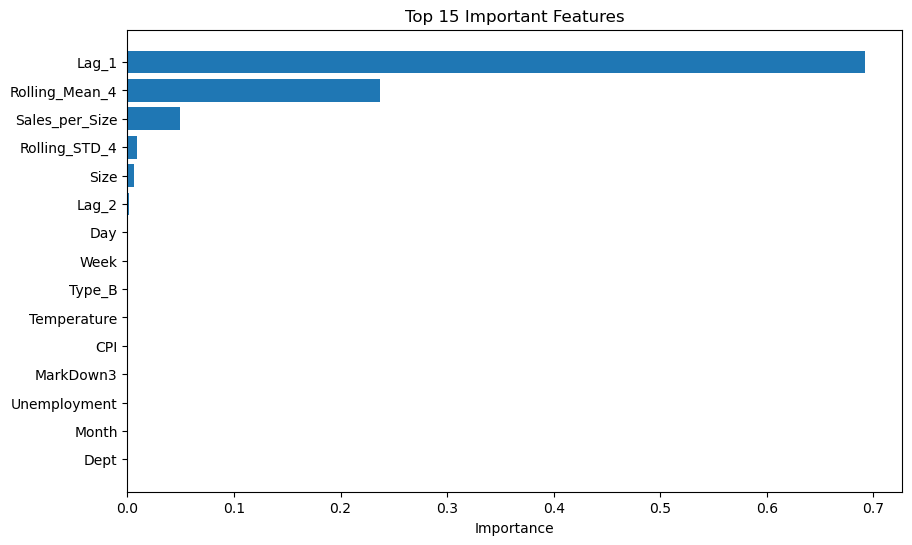

In [17]:
import matplotlib.pyplot as plt

top15 = importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(top15["Feature"], top15["Importance"])

plt.title("Top 15 Important Features")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [18]:
joblib.dump(
    rf,
    "../models/random_forest.pkl"
)

['../models/random_forest.pkl']

In [19]:
print("="*50)
print("Model Training Completed")
print("Best Model Saved Successfully")
print("="*50)

Model Training Completed
Best Model Saved Successfully


# XGBoost

In [20]:
!pip install xgboost

In [21]:
from xgboost import XGBRegressor

In [22]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [23]:
xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [24]:
xgb_pred = xgb.predict(X_test)

In [25]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

print("="*50)
print("XGBoost Results")
print("="*50)

mae = mean_absolute_error(y_test, xgb_pred)
rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
r2 = r2_score(y_test, xgb_pred)

print("MAE :", mae)
print("RMSE :", rmse)
print("R² Score :", r2)

XGBoost Results
MAE : 407.5510344180454
RMSE : 1114.26941350169
R² Score : 0.9976190500664024


In [26]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
22,Rolling_Mean_4,0.530539
20,Lag_1,0.349911
25,Sales_per_Size,0.026016
2,IsHoliday,0.020922
27,Type_C,0.010547
21,Lag_2,0.009658
26,Type_B,0.009153
12,Size,0.006570
23,Rolling_STD_4,0.006249
15,Week,0.004526


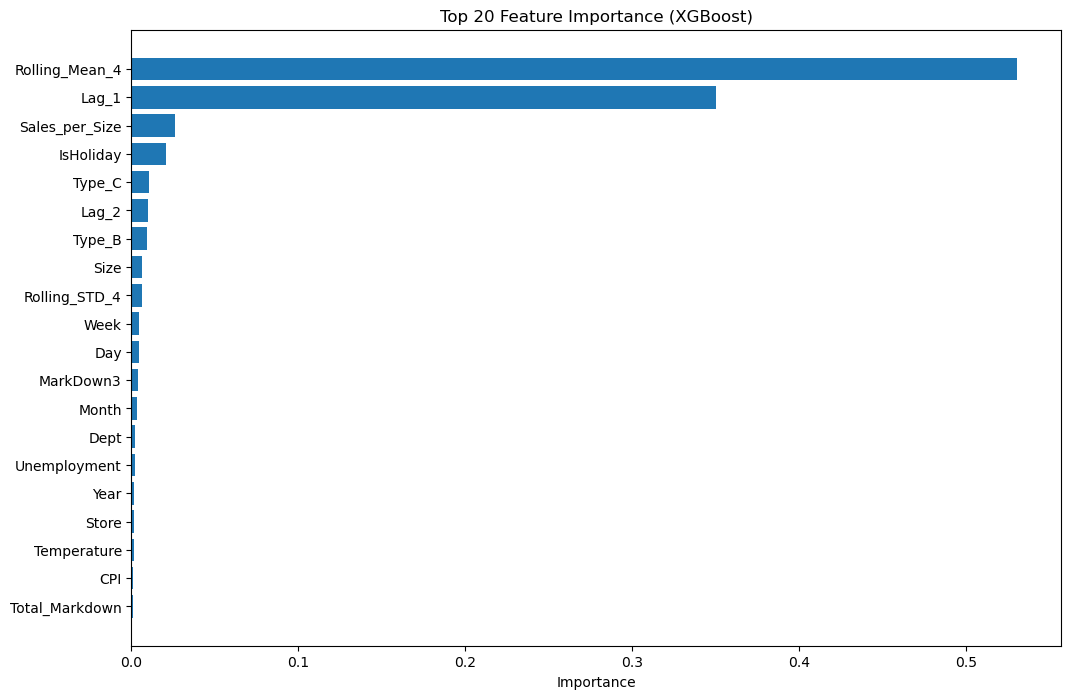

In [27]:
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(12,8))

plt.barh(top20["Feature"], top20["Importance"])

plt.gca().invert_yaxis()

plt.title("Top 20 Feature Importance (XGBoost)")
plt.xlabel("Importance")

plt.show()

In [33]:
import joblib

joblib.dump(xgb, "../models/xgboost.pkl")
print("Model Saved Successfully!")

import os

os.listdir("../models")

Model Saved Successfully!


['.ipynb_checkpoints', 'random_forest.pkl', 'xgboost.pkl']

In [31]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred)
    ]
})

results = results.sort_values(
    by="R2 Score",
    ascending=False
)

results



,Model,MAE,RMSE,R2 Score
2,XGBoost,407.551034,1114.269414,0.997619
1,Random Forest,316.754473,1202.689912,0.997226
0,Linear Regression,2348.298758,5775.385657,0.936037


In [34]:
print(len(X.columns))
print(X.columns.tolist())

28
['Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Size', 'Year', 'Month', 'Week', 'Quarter', 'Day', 'DayOfWeek', 'Weekend', 'Lag_1', 'Lag_2', 'Rolling_Mean_4', 'Rolling_STD_4', 'Total_Markdown', 'Sales_per_Size', 'Type_B', 'Type_C']


In [35]:
print(df.columns.tolist())

['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Size', 'Year', 'Month', 'Week', 'Quarter', 'Day', 'DayOfWeek', 'Weekend', 'Lag_1', 'Lag_2', 'Rolling_Mean_4', 'Rolling_STD_4', 'Total_Markdown', 'Sales_per_Size', 'Type_B', 'Type_C']
